In [1]:
import csv
import logging
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Optional

logging.basicConfig(level=logging.WARNING, format='%(levelname)s: %(message)s')
log = logging.getLogger(__name__)

# Paths 
FORECAST_ROOT = Path('Data/Forecast')

# NWM column names 
COL_NWM_VERSION    = 'NWM_version_number'
COL_NWM_INIT_TIME  = 'model_initialization_time'
COL_NWM_VALID_TIME = 'model_output_valid_time'
COL_NWM_STREAMFLOW = 'streamflow_value'
COL_NWM_STREAM_ID  = 'streamID'
NWM_DATETIME_FMT   = '%Y-%m-%d_%H:%M:%S'

NWM_REQUIRED_COLS: frozenset[str] = frozenset({
    COL_NWM_VERSION, COL_NWM_INIT_TIME, COL_NWM_VALID_TIME,
    COL_NWM_STREAMFLOW, COL_NWM_STREAM_ID,
})

# USGS column names 
COL_USGS_DATETIME        = 'DateTime'
COL_USGS_FLOW            = 'USGSFlowValue'
COL_USGS_QUALITY         = '00060_cd'        
COL_USGS_QUALITY_LEGACY  = 'USGS_GageID'     


# Data structures 
@dataclass
class ForecastRow:
    """A single normalised forecast or observation record."""
    station_id:       Optional[str]
    source:           str                  
    forecast_init:    Optional[datetime]
    forecast_valid:   Optional[datetime]
    streamflow_value: Optional[float]
    nwm_version:      Optional[str]
    quality_code:     Optional[str]


# Parsing helpers 
def try_float(value: Optional[str]) -> Optional[float]:
    """Return *value* as a float, or None if blank/unparseable."""
    if not value:
        return None
    try:
        return float(value)
    except ValueError:
        return None


def parse_nwm_datetime(value: Optional[str]) -> Optional[datetime]:
    """Parse an NWM datetime string (``YYYY-MM-DD_HH:MM:SS``)."""
    if not value:
        return None
    try:
        return datetime.strptime(value, NWM_DATETIME_FMT)
    except ValueError:
        log.warning("Could not parse NWM datetime: %r", value)
        return None


def parse_usgs_datetime(value: Optional[str]) -> Optional[datetime]:
    """Parse a USGS datetime string, stripping timezone info when present."""
    if not value:
        return None
    try:
        dt = datetime.fromisoformat(value)
        return dt.replace(tzinfo=None)
    except ValueError:
        pass
    try:
        return datetime.strptime(value, '%Y-%m-%d %H:%M:%S%z').replace(tzinfo=None)
    except ValueError:
        log.warning("Could not parse USGS datetime: %r", value)
        return None


# CSV loading 
def _detect_format(headers: list[str]) -> str:
    """Return ``'NWM'``, ``'USGS'``, or ``'unknown'`` based on column headers."""
    header_set = set(headers)
    if NWM_REQUIRED_COLS.issubset(header_set):
        return 'NWM'
    if COL_USGS_DATETIME in header_set:
        return 'USGS'
    return 'unknown'


def _parse_nwm_row(raw: dict[str, str], station_id: str) -> ForecastRow:
    return ForecastRow(
        station_id=station_id,
        source='NWM',
        forecast_init=parse_nwm_datetime(raw.get(COL_NWM_INIT_TIME, '')),
        forecast_valid=parse_nwm_datetime(raw.get(COL_NWM_VALID_TIME, '')),
        streamflow_value=try_float(raw.get(COL_NWM_STREAMFLOW, '')),
        nwm_version=raw.get(COL_NWM_VERSION, ''),
        quality_code=None,
    )


def _parse_usgs_row(raw: dict[str, str], station_id: str) -> ForecastRow:
    ts = parse_usgs_datetime(raw.get(COL_USGS_DATETIME, ''))
    quality = raw.get(COL_USGS_QUALITY) or raw.get(COL_USGS_QUALITY_LEGACY, '')
    return ForecastRow(
        station_id=station_id,
        source='USGS',
        forecast_init=ts,
        forecast_valid=ts,
        streamflow_value=try_float(raw.get(COL_USGS_FLOW, '')),
        nwm_version=None,
        quality_code=quality,
    )


def read_forecast_csv(path: Path) -> list[ForecastRow]:
    """Read one forecast CSV and return its rows as :class:`ForecastRow` objects."""
    rows: list[ForecastRow] = []
    with path.open(newline='') as f:
        reader = csv.DictReader(f)
        if reader.fieldnames is None:
            log.warning("Empty or header-less file: %s", path.name)
            return rows

        headers = [h.strip() for h in reader.fieldnames]
        fmt = _detect_format(headers)
        if fmt == 'unknown':
            log.warning("Unrecognised format in %s — skipping", path.name)
            return rows

        # USGS station id is encoded in the filename as '<station_id>_*.csv'
        station_id = path.stem.split('_', 1)[0]

        for raw in reader:
            if fmt == 'NWM':
                rows.append(_parse_nwm_row(raw, station_id))
            else:
                rows.append(_parse_usgs_row(raw, station_id))

    return rows


def load_station_data(station_path: Path) -> list[ForecastRow]:
    """Load and time-sort all CSVs found directly under *station_path*."""
    rows: list[ForecastRow] = []
    for csv_file in sorted(station_path.glob('*.csv')):
        rows.extend(read_forecast_csv(csv_file))

    rows.sort(key=lambda r: (
        r.forecast_valid or datetime.min,
        r.forecast_init  or datetime.min,
    ))
    return rows


# Load all stations 
station_directories = sorted(p for p in FORECAST_ROOT.iterdir() if p.is_dir())
station_data: dict[str, list[ForecastRow]] = {
    d.name: load_station_data(d) for d in station_directories
}


In [3]:
@dataclass
class CleanSummary:
    """Per-station statistics after dropping rows with missing streamflow."""
    total_rows:   int
    cleaned_rows: int
    dropped_rows: int
    drop_rate:    float


def clean_station_data(
    raw: dict[str, list[ForecastRow]],
) -> tuple[dict[str, list[ForecastRow]], dict[str, CleanSummary]]:
    """Drop rows missing a streamflow value and return per-station summaries."""
    cleaned: dict[str, list[ForecastRow]] = {}
    summaries: dict[str, CleanSummary] = {}

    for station_name, rows in raw.items():
        valid    = [r for r in rows if r.streamflow_value is not None]
        dropped  = len(rows) - len(valid)
        cleaned[station_name]  = valid
        summaries[station_name] = CleanSummary(
            total_rows=len(rows),
            cleaned_rows=len(valid),
            dropped_rows=dropped,
            drop_rate=dropped / len(rows) if rows else 0.0,
        )

    return cleaned, summaries


cleaned_station_data, station_summaries = clean_station_data(station_data)

print('Cleaned summary by station:')
for station_name, s in station_summaries.items():
    print(
        f'  {station_name}: '
        f'total={s.total_rows}, '
        f'cleaned={s.cleaned_rows}, '
        f'dropped={s.dropped_rows} ({s.drop_rate:.1%})'
    )


Cleaned summary by station:
  20380357: total=396249, cleaned=396248, dropped=1 (0.0%)
  21609641: total=391658, cleaned=391643, dropped=15 (0.0%)


In [4]:
import pandas as pd
from dataclasses import asdict


def _quality_is_accepted(code: Optional[str]) -> bool:
    """Return False only when the USGS quality string contains the estimated flag 'e'."""
    if not code:
        return True   
    return 'e' not in code.split()


def align_station(rows: list[ForecastRow]) -> pd.DataFrame:
    """Join NWM forecasts to USGS observations for one station.

    Steps:
      1. Filter USGS rows to accepted quality codes (drop estimated 'e' readings).
      2. Resample USGS to hourly mean (USGS is 15-min; NWM is hourly).
      3. Compute NWM lead_hours = forecast_valid − forecast_init.
      4. Inner-join NWM rows to hourly USGS index on forecast_valid.

    Returns a DataFrame with columns:
        forecast_valid, forecast_init, nwm_streamflow,
        usgs_streamflow, lead_hours, station_id
    """
    df = pd.DataFrame([asdict(r) for r in rows])

    nwm  = df[df['source'] == 'NWM'].copy()
    usgs = df[df['source'] == 'USGS'].copy()

    if nwm.empty or usgs.empty:
        return pd.DataFrame()

    # USGS: quality filter → resample to hourly 
    usgs = usgs[usgs['quality_code'].apply(_quality_is_accepted)]
    if usgs.empty:
        return pd.DataFrame()

    usgs['forecast_valid'] = pd.to_datetime(usgs['forecast_valid'])
    usgs_hourly = (
        usgs.set_index('forecast_valid')['streamflow_value']
        .resample('1h').mean()
        .rename('usgs_streamflow')
        .dropna()
    )

    # NWM: compute lead time 
    nwm['forecast_valid'] = pd.to_datetime(nwm['forecast_valid'])
    nwm['forecast_init']  = pd.to_datetime(nwm['forecast_init'])
    nwm['lead_hours'] = (
        (nwm['forecast_valid'] - nwm['forecast_init'])
        .dt.total_seconds()
        .div(3600)
        .round()
        .astype(int)
    )
    nwm = nwm.rename(columns={'streamflow_value': 'nwm_streamflow'})

    # Inner join on forecast_valid timestamp 
    aligned = (
        nwm.set_index('forecast_valid')
        .join(usgs_hourly, how='inner')
        .reset_index()
    )

    keep = ['forecast_valid', 'forecast_init', 'nwm_streamflow',
            'usgs_streamflow', 'lead_hours', 'station_id']
    return aligned[keep].dropna()


aligned_data: dict[str, pd.DataFrame] = {}

for station_name, rows in cleaned_station_data.items():
    df = align_station(rows)
    if df.empty:
        print(f'{station_name}: no aligned pairs found')
        continue
    aligned_data[station_name] = df
    print(
        f'{station_name}: {len(df):,} aligned pairs  '
        f'lead_hours {df["lead_hours"].min()}–{df["lead_hours"].max()}  '
        f'({df["forecast_valid"].min().date()} → {df["forecast_valid"].max().date()})'
    )

print(f'\nTotal across all stations: {sum(len(v) for v in aligned_data.values()):,} paired rows')


20380357: 324,904 aligned pairs  lead_hours 1–18  (2021-04-21 → 2023-04-22)
21609641: 302,406 aligned pairs  lead_hours 1–18  (2021-04-21 → 2023-04-22)

Total across all stations: 627,310 paired rows


In [5]:
import numpy as np

# Season index: 0=winter, 1=spring, 2=summer, 3=autumn
SEASON_MAP: dict[int, int] = {
    12: 0,  1: 0,  2: 0,
     3: 1,  4: 1,  5: 1,
     6: 2,  7: 2,  8: 2,
     9: 3, 10: 3, 11: 3,
}

# Cyclical sin/cos encoding for hour and month avoids the discontinuity at hour 23→0
# and month 12→1 that raw integers introduce.
FEATURE_COLS = [
    'nwm_streamflow',
    'lead_hours',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'season',
]
TARGET_COL = 'usgs_streamflow'


def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Append cyclical hour/month encodings and season derived from forecast_valid."""
    dt    = pd.to_datetime(df['forecast_valid'])
    hour  = dt.dt.hour
    month = dt.dt.month
    return df.assign(
        hour_sin=np.sin(2 * np.pi * hour  / 24),
        hour_cos=np.cos(2 * np.pi * hour  / 24),
        month_sin=np.sin(2 * np.pi * (month - 1) / 12),
        month_cos=np.cos(2 * np.pi * (month - 1) / 12),
        season=month.map(SEASON_MAP),
    )


featured_data: dict[str, pd.DataFrame] = {
    name: add_temporal_features(df.copy())
    for name, df in aligned_data.items()
}


In [ ]:
from sklearn.preprocessing import StandardScaler

TRAIN_END  = pd.Timestamp('2022-06-30 23:00:00')
VAL_END    = pd.Timestamp('2022-09-30 23:00:00')
TEST_START = pd.Timestamp('2022-10-01 00:00:00')

STREAM_COLS = ['nwm_streamflow', TARGET_COL]  
OTHER_COLS  = ['lead_hours', 'season']          

scalers: dict[str, StandardScaler] = {}
splits:  dict[str, dict]           = {}

for station_name, df in featured_data.items():
    df = df.sort_values('forecast_valid').reset_index(drop=True)
    fv = pd.to_datetime(df['forecast_valid'])

    train = df[fv <= TRAIN_END].copy()
    val   = df[(fv > TRAIN_END) & (fv <= VAL_END)].copy()
    test  = df[fv >= TEST_START].copy()

    # Log1p transform on streamflow before scaling — streamflow is right-skewed and
    # log-space brings it closer to Gaussian, which helps the LSTM and the scaler.
    for split in (train, val, test):
        split[STREAM_COLS] = np.log1p(split[STREAM_COLS].clip(lower=0))

    stream_scaler = StandardScaler()
    train[STREAM_COLS] = stream_scaler.fit_transform(train[STREAM_COLS])
    val[STREAM_COLS]   = stream_scaler.transform(val[STREAM_COLS])
    test[STREAM_COLS]  = stream_scaler.transform(test[STREAM_COLS])

    feat_scaler = StandardScaler()
    train[OTHER_COLS] = feat_scaler.fit_transform(train[OTHER_COLS])
    val[OTHER_COLS]   = feat_scaler.transform(val[OTHER_COLS])
    test[OTHER_COLS]  = feat_scaler.transform(test[OTHER_COLS])

    # hour_sin/cos and month_sin/cos are already in [-1, 1] — no scaling needed.

    scalers[station_name] = stream_scaler         
    splits[station_name]  = {
        'train': train, 'val': val, 'test': test,
        'scaler': stream_scaler,                   
    }

    print(f'{station_name}:')
    print(f'  train {len(train):>7,}  {train["forecast_valid"].min().date()} → {train["forecast_valid"].max().date()}')
    print(f'  val   {len(val):>7,}  {val["forecast_valid"].min().date()} → {val["forecast_valid"].max().date()}')
    print(f'  test  {len(test):>7,}  {test["forecast_valid"].min().date()} → {test["forecast_valid"].max().date()}')


20380357:
  train 194,229  2021-04-21 → 2022-06-30
  val    39,850  2022-07-01 → 2022-09-30
  test   90,825  2022-10-01 → 2023-04-22
21609641:
  train 170,541  2021-04-21 → 2022-06-30
  val    41,040  2022-07-01 → 2022-09-30
  test   90,825  2022-10-01 → 2023-04-22


In [ ]:
import numpy as np

SEQ_LEN = 18  

def build_sequences(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Group rows by forecast_init and stack into fixed-length sequences.

    Returns:
        X   - (N, 18, n_features)  model inputs
        y   - (N, 18)              USGS streamflow targets
        nwm - (N, 18)              raw NWM forecast (baseline for evaluation)
    """
    X_list, y_list, nwm_list = [], [], []
    for _, group in df.groupby('forecast_init'):
        group = group.sort_values('lead_hours')
        if len(group) != SEQ_LEN:
            continue  # skip incomplete forecast cycles
        X_list.append(group[FEATURE_COLS].to_numpy(dtype=np.float32))
        y_list.append(group[TARGET_COL].to_numpy(dtype=np.float32))
        nwm_list.append(group['nwm_streamflow'].to_numpy(dtype=np.float32))

    return (
        np.stack(X_list),    # (N, 18, 5)
        np.stack(y_list),    # (N, 18)
        np.stack(nwm_list),  # (N, 18)
    )


seq_data: dict[str, dict] = {}
for station_name, s in splits.items():
    X_tr, y_tr, nwm_tr = build_sequences(s['train'])
    X_va, y_va, nwm_va = build_sequences(s['val'])
    X_te, y_te, nwm_te = build_sequences(s['test'])

    seq_data[station_name] = {
        'X_train': X_tr, 'y_train': y_tr, 'nwm_train': nwm_tr,
        'X_val':   X_va, 'y_val':   y_va, 'nwm_val':   nwm_va,
        'X_test':  X_te, 'y_test':  y_te, 'nwm_test':  nwm_te,
        'scaler':  s['scaler'],
    }
    print(f'{station_name}:  train={X_tr.shape}  val={X_va.shape}  test={X_te.shape}')


20380357:  train=(10110, 18, 7)  val=(2054, 18, 7)  test=(4690, 18, 7)
21609641:  train=(8629, 18, 7)  val=(2119, 18, 7)  test=(4690, 18, 7)


In [ ]:
import tensorflow as tf
from tensorflow import keras

def build_lstm(seq_len: int, n_features: int,
               hidden: int = 64, dropout: float = 0.2) -> keras.Model:
    """Stacked LSTM that corrects NWM forecasts at every lead time simultaneously."""
    inp = keras.Input(shape=(seq_len, n_features), name='forecast_sequence')
    x   = keras.layers.LSTM(hidden, return_sequences=True)(inp)
    x   = keras.layers.Dropout(dropout)(x)
    x   = keras.layers.LSTM(hidden // 2, return_sequences=True)(x)
    x   = keras.layers.Dropout(dropout)(x)
    out = keras.layers.TimeDistributed(keras.layers.Dense(1))(x)
    out = keras.layers.Reshape((seq_len,), name='corrected_streamflow')(out)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3, clipnorm=1.0), loss='mse')
    return model


SEQ_LEN    = 18
N_FEATURES = len(FEATURE_COLS)  

models: dict[str, keras.Model] = {
    name: build_lstm(SEQ_LEN, N_FEATURES) for name in seq_data
}
models[next(iter(models))].summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ forecast_sequence (InputLayer)  │ (None, 18, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 18, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 18, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 18, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ corrected_streamflow (Reshape)  │ (None, 18)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
EPOCHS     = 50
BATCH_SIZE = 256

histories: dict = {}

for station_name, sd in seq_data.items():
    print(f'\n── Training station {station_name} ──')
    model = models[station_name]

    history = model.fit(
        sd['X_train'], sd['y_train'],
        validation_data=(sd['X_val'], sd['y_val']),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=5,
                restore_best_weights=True, verbose=1,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=3, verbose=1,
            ),
        ],
        verbose=1,
    )
    histories[station_name] = history



── Training station 20380357 ──
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.9549 - val_loss: 0.7404 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.9129 - val_loss: 0.7693 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.8972 - val_loss: 0.7505 - learning_rate: 0.0010
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.8891 - val_loss: 0.6949 - learning_rate: 0.0010
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.8791 - val_loss: 0.7850 - learning_rate: 0.0010
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.8726 - val_loss: 0.7192 - learning_rate: 0.0010
Epoch 7/50
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8834
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.8682 - val_loss: 0.7256 - learning_rate: 0.0010
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.8638 - val_l

In [ ]:
import numpy as np

def nse(obs: np.ndarray, sim: np.ndarray) -> float:
    """Nash-Sutcliffe Efficiency. Perfect = 1.0; climatological mean benchmark = 0.0."""
    return float(1.0 - np.sum((obs - sim) ** 2) / np.sum((obs - np.mean(obs)) ** 2))

def rmse(obs: np.ndarray, sim: np.ndarray) -> float:
    return float(np.sqrt(np.mean((obs - sim) ** 2)))

def mae_score(obs: np.ndarray, sim: np.ndarray) -> float:
    return float(np.mean(np.abs(obs - sim)))


def _inv_col(scaled: np.ndarray, scaler: StandardScaler, col: int) -> np.ndarray:
    """Inverse-transform one column of the two-column stream scaler, then undo log1p."""
    flat  = scaled.flatten()
    dummy = np.zeros((len(flat), 2), dtype=np.float64)
    dummy[:, col] = flat
    log_vals = scaler.inverse_transform(dummy)[:, col].reshape(scaled.shape)
    return np.expm1(log_vals)  


for station_name, sd in seq_data.items():
    scaler = sd['scaler']

    y_pred_scaled = models[station_name].predict(sd['X_test'], verbose=0)  

    # Inverse-transform to physical units (col 0 = nwm, col 1 = usgs)
    obs  = _inv_col(sd['y_test'],    scaler, col=1)
    pred = _inv_col(y_pred_scaled,   scaler, col=1)
    nwm  = _inv_col(sd['nwm_test'],  scaler, col=0)

    obs_f, pred_f, nwm_f = obs.flatten(), pred.flatten(), nwm.flatten()

    print(f'\n{station_name} — Test Set (Oct 2022 – Apr 2023)')
    print(f'  {"Model":22s}  {"NSE":>7}  {"RMSE":>8}  {"MAE":>8}')
    print(f'  {"LSTM (corrected)":22s}  {nse(obs_f, pred_f):>7.4f}  {rmse(obs_f, pred_f):>8.4f}  {mae_score(obs_f, pred_f):>8.4f}')
    print(f'  {"NWM (original)":22s}  {nse(obs_f,  nwm_f):>7.4f}  {rmse(obs_f,  nwm_f):>8.4f}  {mae_score(obs_f,  nwm_f):>8.4f}')

    print(f'\n  Per-lead-hour NSE:')
    print(f'  {"Lead":>5}  {"LSTM":>8}  {"NWM":>8}')
    for lead in range(SEQ_LEN):
        print(f'  {lead+1:>4}h  {nse(obs[:, lead], pred[:, lead]):>8.4f}  {nse(obs[:, lead], nwm[:, lead]):>8.4f}')



20380357 — Test Set (Oct 2022 – Apr 2023)
  Model                       NSE      RMSE       MAE
  LSTM (corrected)        -0.1928    0.1914    0.1106
  NWM (original)          -206892.4258   79.7317   58.0047

  Per-lead-hour NSE:
   Lead      LSTM       NWM
     1h   -0.0279  -2341.5859
     2h   -0.0695  -9975.6656
     3h   -0.1244  -28233.0028
     4h   -0.1765  -60144.2970
     5h   -0.2152  -103435.6545
     6h   -0.2376  -148826.5027
     7h   -0.2461  -190508.3363
     8h   -0.2450  -227197.9902
     9h   -0.2390  -255083.4814
    10h   -0.2311  -274598.8767
    11h   -0.2234  -287782.1593
    12h   -0.2168  -296309.9465
    13h   -0.2113  -301658.7847
    14h   -0.2069  -304938.3965
    15h   -0.2034  -306913.8641
    16h   -0.2007  -308064.3004
    17h   -0.1987  -308720.3922
    18h   -0.1974  -309073.2574

21609641 — Test Set (Oct 2022 – Apr 2023)
  Model                       NSE      RMSE       MAE
  LSTM (corrected)         0.8406    6.6381    2.8716
  NWM (original)   

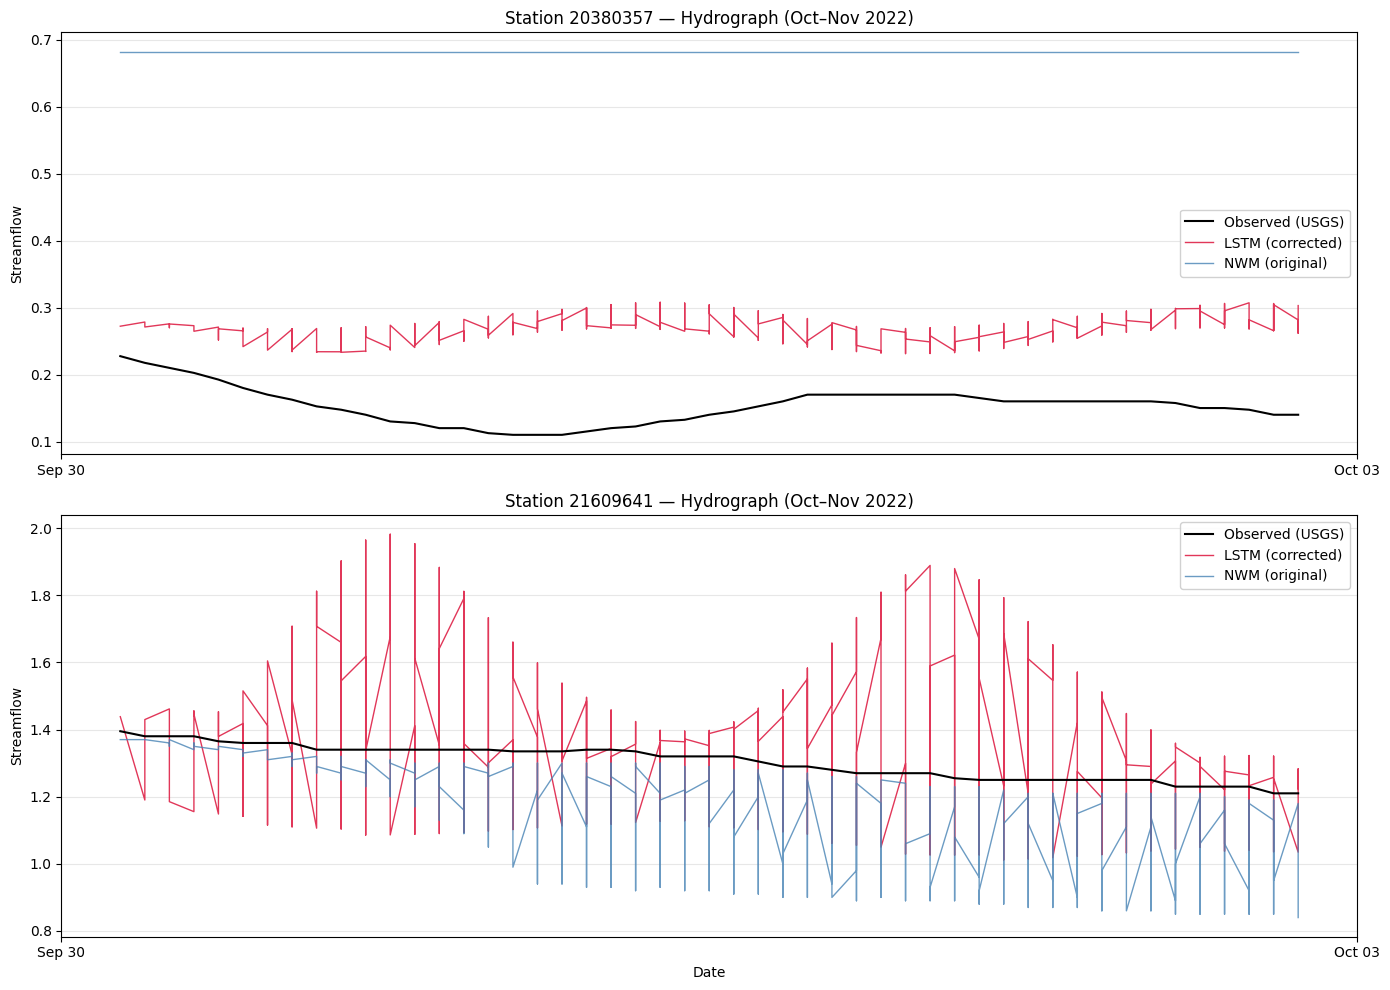

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(seq_data), 1, figsize=(14, 5 * len(seq_data)), sharex=False)
if len(seq_data) == 1:
    axes = [axes]

for ax, (station_name, sd) in zip(axes, seq_data.items()):
    scaler = sd['scaler']
    y_pred_scaled = models[station_name].predict(sd['X_test'], verbose=0)

    obs  = _inv_col(sd['y_test'],   scaler, col=1)
    pred = _inv_col(y_pred_scaled,  scaler, col=1)
    nwm  = _inv_col(sd['nwm_test'], scaler, col=0)

    test_df  = splits[station_name]['test']
    ts_list  = []
    for _, group in test_df.groupby('forecast_init'):
        group = group.sort_values('lead_hours')
        if len(group) != SEQ_LEN:
            continue
        ts_list.append(pd.to_datetime(group['forecast_valid'].to_numpy()))
    timestamps = np.array(ts_list)  # (N, 18)

    ts_flat   = timestamps.flatten()
    obs_flat  = obs.flatten()
    pred_flat = pred.flatten()
    nwm_flat  = nwm.flatten()

    sort_idx  = np.argsort(ts_flat)
    ts_flat   = ts_flat[sort_idx]
    obs_flat  = obs_flat[sort_idx]
    pred_flat = pred_flat[sort_idx]
    nwm_flat  = nwm_flat[sort_idx]

    # Show first 30 days 
    n_plot = min(len(ts_flat), 30 * 24)

    ax.plot(ts_flat[:n_plot], obs_flat[:n_plot],  label='Observed (USGS)',  color='black',     lw=1.5, zorder=3)
    ax.plot(ts_flat[:n_plot], pred_flat[:n_plot], label='LSTM (corrected)', color='crimson',   lw=1.0, alpha=0.85)

    # NWM values for station 20380357 are on a very different scale 
    obs_lo, obs_hi = obs_flat[:n_plot].min(), obs_flat[:n_plot].max()
    nwm_clipped = np.clip(nwm_flat[:n_plot], obs_lo - abs(obs_hi) * 0.5, obs_hi * 3)
    ax.plot(ts_flat[:n_plot], nwm_clipped,        label='NWM (original)',   color='steelblue', lw=1.0, alpha=0.8)

    ax.set_title(f'Station {station_name} — Hydrograph (Oct–Nov 2022)', fontsize=12)
    ax.set_ylabel('Streamflow')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.legend(framealpha=0.9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.tight_layout()
plt.savefig('hydrograph_test_period.png', dpi=150, bbox_inches='tight')
plt.show()


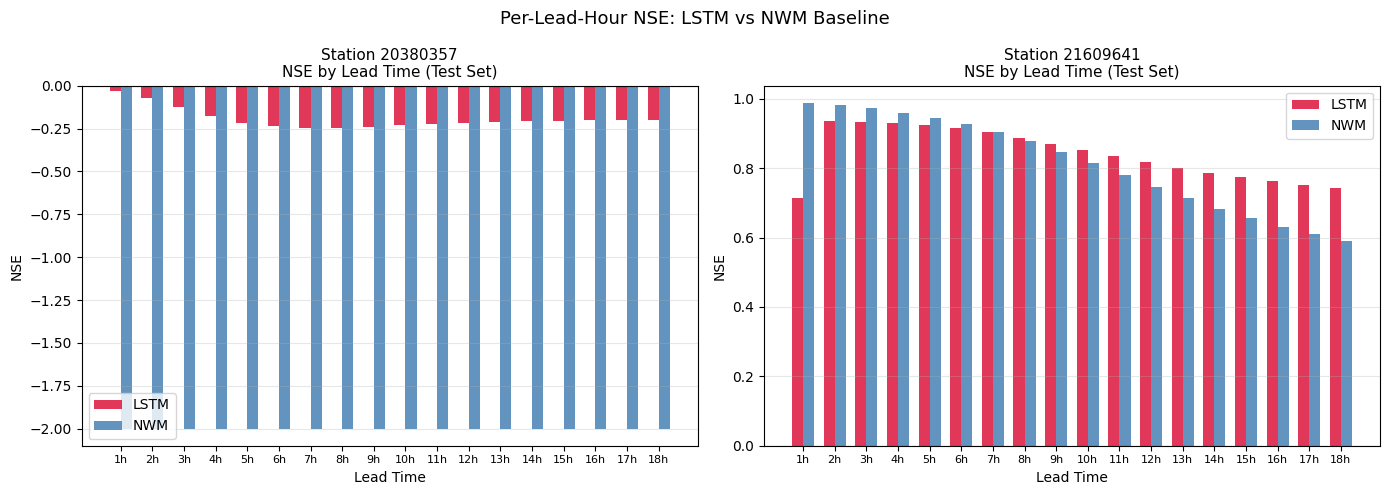

In [ ]:
lead_hours = np.arange(1, SEQ_LEN + 1)
bar_width   = 0.35
x           = np.arange(SEQ_LEN)

fig, axes = plt.subplots(1, len(seq_data), figsize=(7 * len(seq_data), 5), sharey=False)
if len(seq_data) == 1:
    axes = [axes]

for ax, (station_name, sd) in zip(axes, seq_data.items()):
    scaler = sd['scaler']
    y_pred_scaled = models[station_name].predict(sd['X_test'], verbose=0)

    obs  = _inv_col(sd['y_test'],   scaler, col=1)
    pred = _inv_col(y_pred_scaled,  scaler, col=1)
    nwm  = _inv_col(sd['nwm_test'], scaler, col=0)

    lstm_nse_per_lead = [nse(obs[:, l], pred[:, l]) for l in range(SEQ_LEN)]
    nwm_nse_per_lead  = [nse(obs[:, l], nwm[:, l])  for l in range(SEQ_LEN)]
    
    nwm_plot = np.clip(nwm_nse_per_lead, -2.0, 1.0)

    ax.bar(x - bar_width / 2, lstm_nse_per_lead, bar_width, label='LSTM', color='crimson',   alpha=0.85)
    ax.bar(x + bar_width / 2, nwm_plot,          bar_width, label='NWM',  color='steelblue', alpha=0.85)

    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{h}h' for h in lead_hours], fontsize=8)
    ax.set_xlabel('Lead Time')
    ax.set_ylabel('NSE')
    ax.set_title(f'Station {station_name}\nNSE by Lead Time (Test Set)', fontsize=11)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Per-Lead-Hour NSE: LSTM vs NWM Baseline', fontsize=13)
fig.tight_layout()
plt.savefig('per_lead_nse.png', dpi=150, bbox_inches='tight')
plt.show()
